# Convergent Probe CBED — Au [100]



Thickness-resolved high-angle CBED comparison for Au [100].



- **Ground truth**: Second-Order Wave ODE sampled at every unit-cell exit plane

- **Test methods**: Fresnel multislice, Angular Spectrum multislice, and WPM

- **Probe angles**: 25, 50, 100, and 200 mrad

- **Thickness**: repeated Au [100] unit cells up to approximately 100 nm

- **Z-sampling**: configured below; a quick 128-vs-256 slices/cell check is run before the full series

- **Stored outputs**: per-unit-cell errors, per-unit-cell timings, and final CBED patterns for later plotting

In [10]:
%matplotlib inline

import os
from pathlib import Path
from time import perf_counter

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".7"

import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk, surface
from matplotlib.colors import LogNorm, TwoSlopeNorm

from wide_angle_propagation.propagation_methods import (
    angular_spectrum_propagation_kernel,
    energy2wavelength,
    fresnel_propagation_kernel,
    simulate_fresnel_as,
    simulate_kg_ode_full,
    simulate_wpm,
)

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)


## Experiment setup



The simulation uses one Au [100] unit cell potential and repeats it until the cumulative thickness reaches approximately 100 nm. Results are recorded after each unit cell.

In [11]:
# --- Experiment parameters ---
energy = 200e3
a_Au = 4.076
TARGET_THICKNESS_NM = 100.0
PROBE_ANGLES_MRAD = np.array([5.0, 25.0, 50.0, 100.0], dtype=float)

# Recommended for 200 mrad with a ~10-12 Å field of view.
ODE_GPTS = (256, 256)
ODE_SLICES_PER_CELL = 128
TEST_SLICES_PER_CELL = 128

RUN_WPM = True
SAVE_RESULTS_NPZ = True
LOAD_EXISTING_RESULTS = False
RECOMPUTE_SIMULATION = True
RESULTS_FILENAME = "cbed_thickness_series_au100_100nm.npz"

CENTRAL_ZOOM_OUTER_FRACTION = 1.25
# Single cutoff used for all CBED image panels (same angular window everywhere).
CENTRAL_VIEW_CUTOFF_MRAD = 100.0

# --- Build Au [100] cubic unit cell ---
unit_cell = bulk("Au", "fcc", a=a_Au, cubic=True)
unit_cell.pbc = [True, True, True]

z_period = a_Au
nx_rep = int(np.ceil(10 / unit_cell.cell.lengths()[0]))
ny_rep = int(np.ceil(10 / unit_cell.cell.lengths()[1]))
n_unit_cells = int(np.ceil((10.0 * TARGET_THICKNESS_NM) / z_period))
actual_thickness_nm = n_unit_cells * z_period / 10.0
thickness_nm = np.arange(1, n_unit_cells + 1, dtype=float) * z_period / 10.0

# Build only one periodic unit cell along z; the propagation loop repeats it.
unit_supercell = unit_cell * (nx_rep, ny_rep, 1)
wavelength = float(energy2wavelength(energy))
dz_ode = z_period / ODE_SLICES_PER_CELL
dz_test = z_period / TEST_SLICES_PER_CELL

print(f"Au [100], {energy/1e3:.0f} keV, λ = {wavelength:.4f} Å")
print(f"Target thickness = {TARGET_THICKNESS_NM:.1f} nm; actual = {actual_thickness_nm:.1f} nm")
print(f"Unit-cell repeats = {n_unit_cells}, z-period = {z_period:.4f} Å")
print(f"Probe angles = {PROBE_ANGLES_MRAD} mrad")
print(f"ODE:  gpts={ODE_GPTS}, {ODE_SLICES_PER_CELL} slices/cell, dz={dz_ode:.4f} Å")
print(f"Test: {TEST_SLICES_PER_CELL} slices/cell, dz={dz_test:.4f} Å")


Au [100], 200 keV, λ = 0.0251 Å
Target thickness = 100.0 nm; actual = 100.3 nm
Unit-cell repeats = 246, z-period = 4.0760 Å
Probe angles = [  5.  25.  50. 100.] mrad
ODE:  gpts=(256, 256), 128 slices/cell, dz=0.0318 Å
Test: 128 slices/cell, dz=0.0318 Å


## Build one-cell potentials and helper functions



The ODE and test-method potentials use the same lateral grid. The z-sampling values are configured in the parameter cell above, and the quick check below compares 128 and 256 slices per unit cell before the full run.

In [12]:
existing_results_path = Path("notebooks") / "cbed" / "results" / RESULTS_FILENAME
if not existing_results_path.exists():
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidate = base / "notebooks" / "cbed" / "results" / RESULTS_FILENAME
        if candidate.exists():
            existing_results_path = candidate
            break

if LOAD_EXISTING_RESULTS and existing_results_path.exists() and not RECOMPUTE_SIMULATION:
    with np.load(existing_results_path, allow_pickle=True) as saved_data:
        gpts = tuple(int(value) for value in saved_data["gpts"])
        sampling = tuple(float(value) for value in saved_data["sampling_A"])
    ny_g, nx_g = gpts
    pot_ode_cell = pot_test_cell = fk = ak = None
    print(f"Using saved results -> {existing_results_path}")
    print(f"Loaded grid: {gpts}, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) Å")
else:
    print("Building one-cell ODE reference potential...")
    pot_ode_abtem = abtem.Potential(
        unit_supercell,
        gpts=ODE_GPTS,
        slice_thickness=dz_ode,
        projection="finite",
        parametrization="lobato",
    )
    gpts = tuple(pot_ode_abtem.gpts)
    sampling = (float(pot_ode_abtem.sampling[0]), float(pot_ode_abtem.sampling[1]))
    pot_ode_cell = jnp.array(cupy.asnumpy(pot_ode_abtem.build(lazy=False).array) / dz_ode)
    del pot_ode_abtem
    cupy.get_default_memory_pool().free_all_blocks()
    print(f"  ODE one-cell potential shape: {pot_ode_cell.shape}")

    print("Building one-cell test-method potential...")
    pot_test_abtem = abtem.Potential(
        unit_supercell,
        gpts=gpts,
        slice_thickness=dz_test,
        projection="finite",
        parametrization="lobato",
    )
    pot_test_cell = jnp.array(cupy.asnumpy(pot_test_abtem.build(lazy=False).array) / dz_test)
    del pot_test_abtem
    cupy.get_default_memory_pool().free_all_blocks()
    print(f"  Test one-cell potential shape: {pot_test_cell.shape}")

    fk = jnp.array(fresnel_propagation_kernel(*gpts, sampling, z=dz_test, energy=energy))
    ak = jnp.array(angular_spectrum_propagation_kernel(*gpts, sampling, z=dz_test, energy=energy))
    ny_g, nx_g = gpts

nyquist_angle_mrad = 1e3 * np.arcsin(np.clip(wavelength / (2 * max(sampling)), 0.0, 1.0))
print(f"Grid: {gpts}, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) Å")
print(f"Nyquist scattering angle ≈ {nyquist_angle_mrad:.1f} mrad")
if PROBE_ANGLES_MRAD.max() > 0.8 * nyquist_angle_mrad:
    print("Warning: largest probe angle is close to the grid Nyquist angle; consider a finer grid.")


def make_convergent_probe(semi_angle_mrad_val, ny, nx, samp_y, samp_x, wavelength_ang):
    alpha = semi_angle_mrad_val * 1e-3
    k_max = np.sin(alpha) / wavelength_ang
    fy = np.fft.fftfreq(ny, d=samp_y)
    fx = np.fft.fftfreq(nx, d=samp_x)
    fx_grid, fy_grid = np.meshgrid(fx, fy)
    aperture = (np.sqrt(fx_grid**2 + fy_grid**2) <= k_max).astype(np.complex128)
    n_pix = float(aperture.real.sum())
    if n_pix == 0:
        raise ValueError(f"No aperture pixels for semi-angle {semi_angle_mrad_val} mrad")
    aperture /= np.sqrt(n_pix)
    probe = np.fft.fftshift(np.fft.ifft2(aperture))
    return jnp.array(probe, dtype=jnp.complex128)


def diffraction_pattern(exit_wave):
    wave = np.asarray(exit_wave)
    return np.abs(np.fft.fftshift(np.fft.fft2(wave))) ** 2


def cbed_amplitude(pattern_intensity):
    return np.sqrt(np.maximum(np.asarray(pattern_intensity), 0.0))


def relative_rmse(pattern, reference):
    pattern = np.asarray(pattern)
    reference = np.asarray(reference)
    return float(np.sqrt(np.mean((pattern - reference) ** 2)) / np.sqrt(np.mean(reference ** 2)))


def diffraction_angle_axes_mrad(ny, nx, samp_y, samp_x, wavelength_ang):
    fy = np.fft.fftshift(np.fft.fftfreq(ny, d=samp_y))
    fx = np.fft.fftshift(np.fft.fftfreq(nx, d=samp_x))
    theta_y = 1e3 * np.arcsin(np.clip(wavelength_ang * fy, -1.0, 1.0))
    theta_x = 1e3 * np.arcsin(np.clip(wavelength_ang * fx, -1.0, 1.0))
    return theta_y, theta_x


def central_crop_slices(semi_angle_mrad_val, ny, nx, samp_y, samp_x, wavelength_ang):
    theta_y, theta_x = diffraction_angle_axes_mrad(ny, nx, samp_y, samp_x, wavelength_ang)
    half_width = CENTRAL_ZOOM_OUTER_FRACTION * semi_angle_mrad_val
    y_idx = np.where(np.abs(theta_y) <= half_width)[0]
    x_idx = np.where(np.abs(theta_x) <= half_width)[0]
    if y_idx.size == 0 or x_idx.size == 0:
        raise ValueError(f"No central crop pixels for semi-angle {semi_angle_mrad_val} mrad")
    return slice(y_idx[0], y_idx[-1] + 1), slice(x_idx[0], x_idx[-1] + 1), theta_y, theta_x


def central_crop_slices_by_cutoff(cutoff_mrad, ny, nx, samp_y, samp_x, wavelength_ang):
    theta_y, theta_x = diffraction_angle_axes_mrad(ny, nx, samp_y, samp_x, wavelength_ang)
    y_idx = np.where(np.abs(theta_y) <= cutoff_mrad)[0]
    x_idx = np.where(np.abs(theta_x) <= cutoff_mrad)[0]
    if y_idx.size == 0 or x_idx.size == 0:
        raise ValueError(f"No central crop pixels for cutoff {cutoff_mrad} mrad")
    return slice(y_idx[0], y_idx[-1] + 1), slice(x_idx[0], x_idx[-1] + 1), theta_y, theta_x


Building one-cell ODE reference potential...
  ODE one-cell potential shape: (128, 256, 256)
Building one-cell test-method potential...
  Test one-cell potential shape: (128, 256, 256)
Grid: (256, 256), sampling = (0.0478, 0.0478) Å
Nyquist scattering angle ≈ 265.6 mrad


## Load or run thickness-resolved CBED series



If a compact results file already exists, the notebook can reconstruct the stored error curves and final CBED patterns without rerunning the expensive propagation. Set `RECOMPUTE_SIMULATION = True` to regenerate the data.

In [ ]:
def resolve_repo_root():
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if (base / "notebooks").exists() and (base / "Paper").exists():
            return base
    return cwd


def results_file_path():
    return resolve_repo_root() / "notebooks" / "cbed" / "results" / RESULTS_FILENAME


def reconstruct_results_from_npz(path):
    with np.load(path, allow_pickle=True) as data:
        loaded_methods = [str(name) for name in data["method_names"]]
        loaded_angles = data["probe_angles_mrad"].astype(float)
        loaded_metadata = dict(data["metadata"][0])
        loaded_error_metric = str(loaded_metadata.get("error_metric", "cbed_intensity_rmse"))
        if loaded_error_metric != "cbed_amplitude_rmse":
            raise ValueError(
                "Saved CBED results contain diffraction-intensity RMSE curves. "
                "Set RECOMPUTE_SIMULATION = True and rerun from the potential-building cell to regenerate amplitude-based curves."
            )
        loaded_results = {
            "metadata": loaded_metadata,
            "thickness_nm": data["thickness_nm"].copy(),
            "angles": {},
        }
        for alpha in loaded_angles:
            angle_key = f"angle_{alpha:.0f}mrad"
            angle_results = {
                "rel_l2": {},
                "runtime_s": {},
                "final_patterns": {
                    "KG ODE": data[f"{angle_key}_kg_ode_final_pattern"].copy(),
                },
                "final_exit_waves": {},
            }
            angle_results["runtime_s"]["KG ODE"] = data[f"{angle_key}_kg_ode_runtime_s"].copy()
            for method in loaded_methods:
                method_key = method.lower().replace(" ", "_")
                angle_results["rel_l2"][method] = data[f"{angle_key}_{method_key}_rel_l2"].copy()
                angle_results["runtime_s"][method] = data[f"{angle_key}_{method_key}_runtime_s"].copy()
                angle_results["final_patterns"][method] = data[f"{angle_key}_{method_key}_final_pattern"].copy()
            loaded_results["angles"][float(alpha)] = angle_results
    return loaded_angles, loaded_methods, loaded_results


method_names = ["Fresnel MS", "Angular Spectrum", "WPM"] if RUN_WPM else ["Fresnel MS", "Angular Spectrum"]
existing_results_path = results_file_path()

if LOAD_EXISTING_RESULTS and existing_results_path.exists() and not RECOMPUTE_SIMULATION:
    PROBE_ANGLES_MRAD, method_names, cbed_results = reconstruct_results_from_npz(existing_results_path)
    thickness_nm = cbed_results["thickness_nm"]
    print(f"Loaded saved CBED results -> {existing_results_path}")
    print(f"Loaded {len(PROBE_ANGLES_MRAD)} angles and {len(thickness_nm)} thickness points")
else:
    method_names = ["Fresnel MS", "Angular Spectrum", "WPM"] if RUN_WPM else ["Fresnel MS", "Angular Spectrum"]

    cbed_results = {
        "metadata": {
            "energy_eV": energy,
            "wavelength_A": wavelength,
            "gpts": gpts,
            "sampling_A": sampling,
            "target_thickness_nm": TARGET_THICKNESS_NM,
            "actual_thickness_nm": actual_thickness_nm,
            "n_unit_cells": n_unit_cells,
            "ode_slices_per_cell": ODE_SLICES_PER_CELL,
            "test_slices_per_cell": TEST_SLICES_PER_CELL,
            "probe_angles_mrad": PROBE_ANGLES_MRAD.copy(),
            "error_metric": "cbed_amplitude_rmse",
        },
        "thickness_nm": thickness_nm.copy(),
        "angles": {},
    }

    for alpha in PROBE_ANGLES_MRAD:
        print("=" * 72)
        print(f"Angle {alpha:.0f} mrad: propagating {n_unit_cells} unit cells")
        print("=" * 72)

        probe = make_convergent_probe(alpha, ny_g, nx_g, sampling[0], sampling[1], wavelength)

        waves = {
            "KG ODE": probe,
            "Fresnel MS": probe,
            "Angular Spectrum": probe,
        }
        if RUN_WPM:
            waves["WPM"] = probe
        phi_ode = None

        angle_results = {
            "rel_l2": {name: np.empty(n_unit_cells, dtype=float) for name in method_names},
            "runtime_s": {"KG ODE": np.empty(n_unit_cells, dtype=float), **{name: np.empty(n_unit_cells, dtype=float) for name in method_names}},
            "final_patterns": {},
            "final_exit_waves": {},
        }

        for cell_index in range(n_unit_cells):
            if cell_index == 0 or (cell_index + 1) % 25 == 0 or (cell_index + 1) == n_unit_cells:
                print(f"  Unit cell {cell_index + 1}/{n_unit_cells} ({thickness_nm[cell_index]:.1f} nm)")

            t0 = perf_counter()
            waves["KG ODE"], phi_ode, dp_ode_raw, _ = simulate_kg_ode_full(
                pot_ode_cell,
                waves["KG ODE"],
                dz_ode,
                energy,
                sampling,
                initial_phi=phi_ode,
                save_wavefronts=False,
            )
            angle_results["runtime_s"]["KG ODE"][cell_index] = perf_counter() - t0
            dp_ode = np.asarray(dp_ode_raw)
            amp_ode = cbed_amplitude(dp_ode)

            t0 = perf_counter()
            waves["Fresnel MS"], _, _ = simulate_fresnel_as(
                pot_test_cell,
                waves["Fresnel MS"],
                fk,
                dz_test,
                energy,
            )
            angle_results["runtime_s"]["Fresnel MS"][cell_index] = perf_counter() - t0
            dp_fresnel = diffraction_pattern(waves["Fresnel MS"])
            angle_results["rel_l2"]["Fresnel MS"][cell_index] = relative_rmse(cbed_amplitude(dp_fresnel), amp_ode)

            t0 = perf_counter()
            waves["Angular Spectrum"], _, _ = simulate_fresnel_as(
                pot_test_cell,
                waves["Angular Spectrum"],
                ak,
                dz_test,
                energy,
            )
            angle_results["runtime_s"]["Angular Spectrum"][cell_index] = perf_counter() - t0
            dp_as = diffraction_pattern(waves["Angular Spectrum"])
            angle_results["rel_l2"]["Angular Spectrum"][cell_index] = relative_rmse(cbed_amplitude(dp_as), amp_ode)

            if RUN_WPM:
                t0 = perf_counter()
                waves["WPM"], _, _ = simulate_wpm(
                    pot_test_cell,
                    waves["WPM"],
                    dz_test,
                    energy,
                    sampling,
                )
                angle_results["runtime_s"]["WPM"][cell_index] = perf_counter() - t0
                dp_wpm = diffraction_pattern(waves["WPM"])
                angle_results["rel_l2"]["WPM"][cell_index] = relative_rmse(cbed_amplitude(dp_wpm), amp_ode)

        angle_results["final_patterns"]["KG ODE"] = dp_ode
        angle_results["final_patterns"]["Fresnel MS"] = diffraction_pattern(waves["Fresnel MS"])
        angle_results["final_patterns"]["Angular Spectrum"] = diffraction_pattern(waves["Angular Spectrum"])
        if RUN_WPM:
            angle_results["final_patterns"]["WPM"] = diffraction_pattern(waves["WPM"])

        angle_results["final_exit_waves"] = {name: np.asarray(wave) for name, wave in waves.items()}
        cbed_results["angles"][float(alpha)] = angle_results
        cupy.get_default_memory_pool().free_all_blocks()

    print("Thickness-resolved CBED series complete.")


Angle 5 mrad: propagating 246 unit cells
  Unit cell 1/246 (0.4 nm)
  Unit cell 25/246 (10.2 nm)
  Unit cell 50/246 (20.4 nm)
  Unit cell 75/246 (30.6 nm)
  Unit cell 100/246 (40.8 nm)
  Unit cell 125/246 (50.9 nm)
  Unit cell 150/246 (61.1 nm)
  Unit cell 175/246 (71.3 nm)
  Unit cell 200/246 (81.5 nm)
  Unit cell 225/246 (91.7 nm)
  Unit cell 246/246 (100.3 nm)
Angle 25 mrad: propagating 246 unit cells
  Unit cell 1/246 (0.4 nm)
  Unit cell 25/246 (10.2 nm)
  Unit cell 50/246 (20.4 nm)
  Unit cell 75/246 (30.6 nm)
  Unit cell 100/246 (40.8 nm)
  Unit cell 125/246 (50.9 nm)
  Unit cell 150/246 (61.1 nm)
  Unit cell 175/246 (71.3 nm)
  Unit cell 200/246 (81.5 nm)
  Unit cell 225/246 (91.7 nm)
  Unit cell 246/246 (100.3 nm)
Angle 50 mrad: propagating 246 unit cells
  Unit cell 1/246 (0.4 nm)
  Unit cell 25/246 (10.2 nm)
  Unit cell 50/246 (20.4 nm)
  Unit cell 75/246 (30.6 nm)
  Unit cell 100/246 (40.8 nm)
  Unit cell 125/246 (50.9 nm)
  Unit cell 150/246 (61.1 nm)
  Unit cell 175/246 (

## Save compact results for later plotting



The saved file contains metadata, the thickness axis, per-method error curves, runtime curves, and final CBED patterns. It does not store every full diffraction pattern at every thickness, which would be several gigabytes.

In [ ]:
if SAVE_RESULTS_NPZ:
    repo_root = Path.cwd().resolve()
    for base in [repo_root, *repo_root.parents]:
        if (base / "notebooks").exists() and (base / "Paper").exists():
            repo_root = base
            break

    output_dir = repo_root / "notebooks" / "cbed" / "results"
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / RESULTS_FILENAME

    arrays_to_save = {
        "thickness_nm": cbed_results["thickness_nm"],
        "probe_angles_mrad": PROBE_ANGLES_MRAD,
        "method_names": np.array(method_names, dtype=object),
        "gpts": np.array(gpts),
        "sampling_A": np.array(sampling),
        "metadata": np.array([cbed_results["metadata"]], dtype=object),
        "central_zoom_outer_fraction": np.array(CENTRAL_ZOOM_OUTER_FRACTION),
    }
    for alpha, angle_results in cbed_results["angles"].items():
        angle_key = f"angle_{alpha:.0f}mrad"
        for method in method_names:
            method_key = method.lower().replace(" ", "_")
            arrays_to_save[f"{angle_key}_{method_key}_rel_l2"] = angle_results["rel_l2"][method]
            arrays_to_save[f"{angle_key}_{method_key}_runtime_s"] = angle_results["runtime_s"][method]
            arrays_to_save[f"{angle_key}_{method_key}_final_pattern"] = angle_results["final_patterns"][method]
        arrays_to_save[f"{angle_key}_kg_ode_runtime_s"] = angle_results["runtime_s"]["KG ODE"]
        arrays_to_save[f"{angle_key}_kg_ode_final_pattern"] = angle_results["final_patterns"]["KG ODE"]

    np.savez_compressed(output_path, **arrays_to_save)
    print(f"Saved compact results -> {output_path}")


Saved compact results -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/cbed/results/cbed_thickness_series_au100_100nm.npz


## Error versus thickness



Each panel is one probe semi-angle.



Curves show relative RMSE of CBED diffraction-pattern amplitude against KG ODE at the end of every unit cell, not exit-wave amplitude.



Lower values indicate closer agreement. Values above 1 are possible for large deviations.

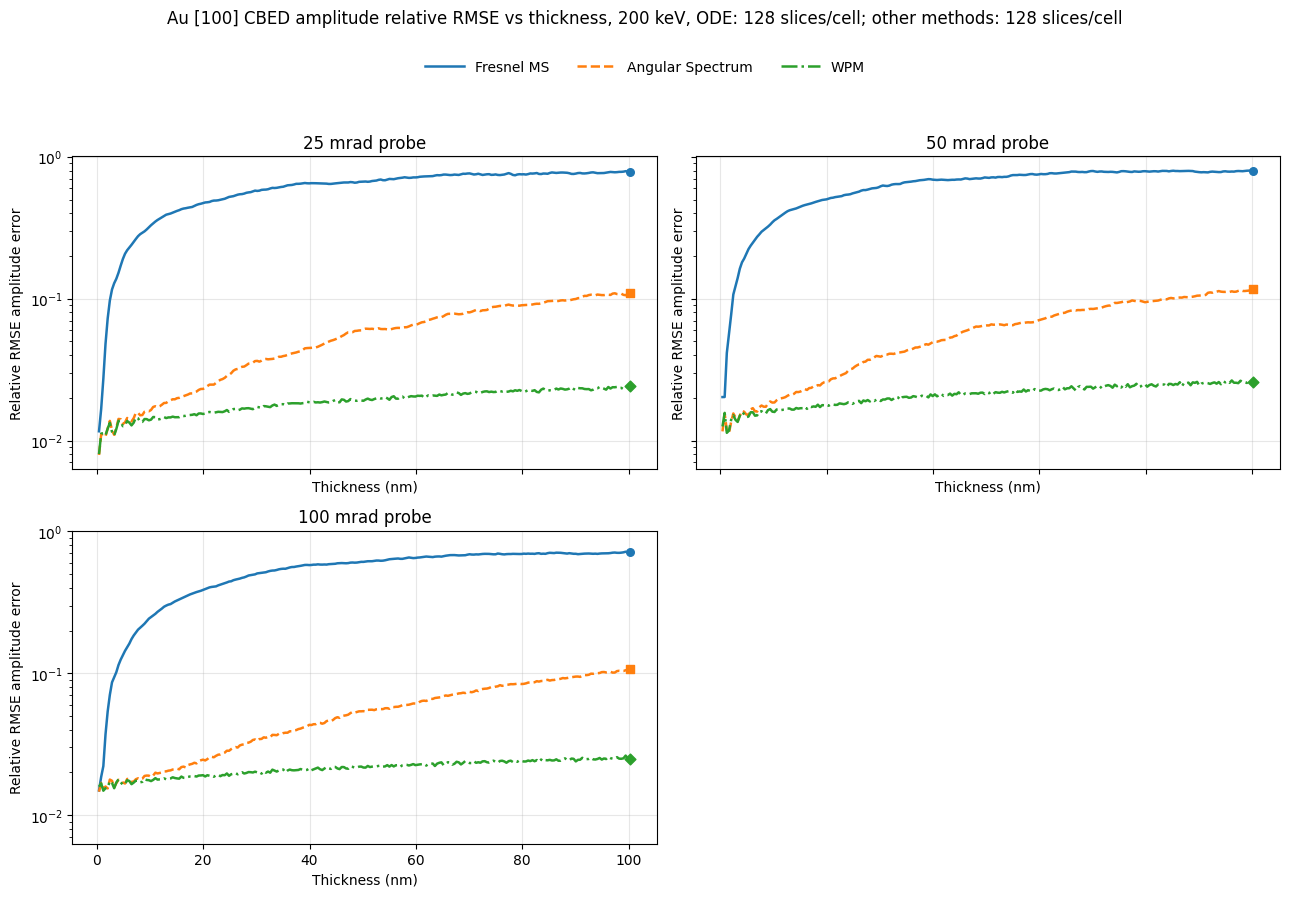

In [ ]:
plot_methods = method_names
colors = {"Fresnel MS": "C0", "Angular Spectrum": "C1", "WPM": "C2"}
line_styles = {"Fresnel MS": "-", "Angular Spectrum": "--", "WPM": "-."}
end_markers = {"Fresnel MS": "o", "Angular Spectrum": "s", "WPM": "D"}

n_angles = len(PROBE_ANGLES_MRAD)
ncols = 2
nrows = int(np.ceil(n_angles / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.8 * nrows), sharex=True, sharey=True)
axes = np.asarray(axes).reshape(-1)

legend_handles = {}
for ax, alpha in zip(axes, PROBE_ANGLES_MRAD):
    angle_results = cbed_results["angles"][float(alpha)]
    for method in plot_methods:
        y = angle_results["rel_l2"][method]
        x = cbed_results["thickness_nm"]
        line, = ax.semilogy(
            x,
            y,
            color=colors[method],
            linestyle=line_styles[method],
            linewidth=1.8,
            label=method,
        )
        ax.scatter(
            x[-1],
            y[-1],
            color=colors[method],
            marker=end_markers[method],
            s=30,
            zorder=4,
        )
        if method not in legend_handles:
            legend_handles[method] = line
    ax.set_title(f"{alpha:.0f} mrad probe")
    ax.set_xlabel("Thickness (nm)")
    ax.set_ylabel("Relative RMSE amplitude error")
    ax.grid(True, alpha=0.3)

for ax in axes[n_angles:]:
    ax.axis("off")

fig.suptitle(
    f"Au [100] CBED amplitude relative RMSE vs thickness, {energy/1e3:.0f} keV, "
    f"ODE: {ODE_SLICES_PER_CELL} slices/cell; other methods: {TEST_SLICES_PER_CELL} slices/cell",
    fontsize=12,
    y=0.98,
)

ordered_handles = [legend_handles[m] for m in plot_methods if m in legend_handles]
ordered_labels = [m for m in plot_methods if m in legend_handles]
fig.legend(
    ordered_handles,
    ordered_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.94),
    ncol=max(1, len(ordered_labels)),
    frameon=False,
    fontsize=10,
    handlelength=2.8,
 )

plt.tight_layout(rect=[0.0, 0.05, 1.0, 0.90])
plt.show()


## Paper-ready combined CBED figure

Per probe angle, shows the KG ODE CBED amplitude alongside each test method's amplitude and its pixel-wise percent amplitude error on a shared log color scale. Exports `Paper/figures/cbed_combined_amplitude_log_error_maps.pdf`.

Saved -> /home/dl277493/Documents/Code/WideAnglePropagation/Paper/figures/cbed_combined_amplitude_log_error_maps.pdf


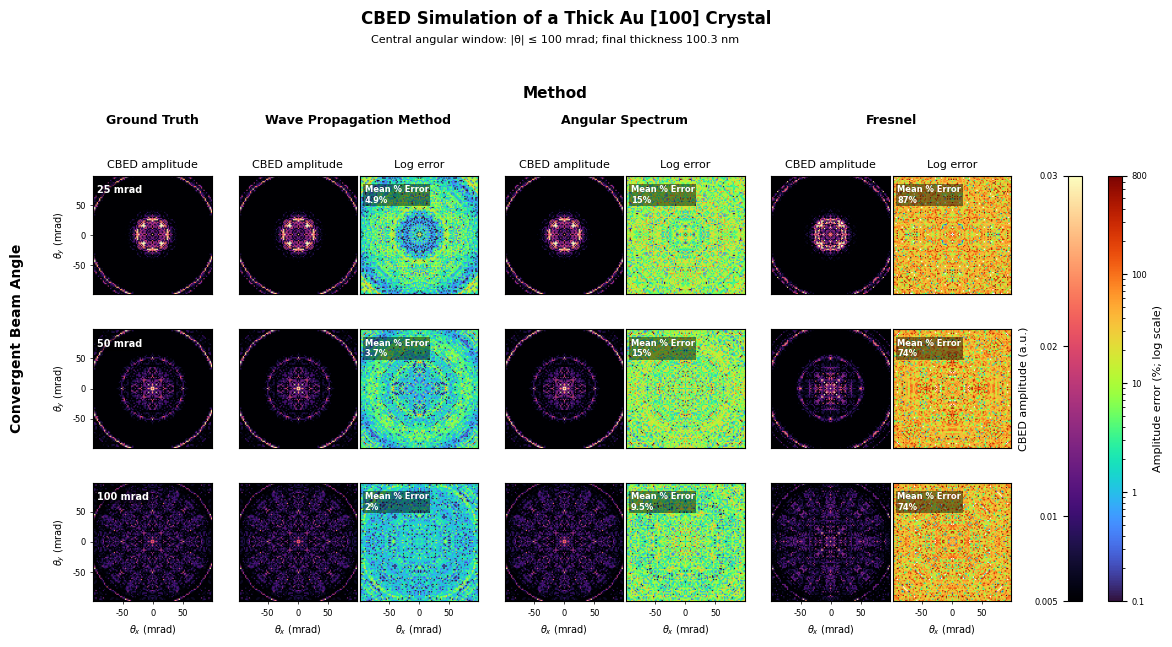

In [ ]:
# Paper-ready combined CBED amplitude + log percent-error figure.
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm, Normalize

# --- Tunable controls -------------------------------------------------
RESULTS_FILENAME = globals().get("RESULTS_FILENAME", "cbed_thickness_series_au100_100nm.npz")
COMBINED_OUTPUT_FILENAME = "cbed_combined_amplitude_log_error_maps.pdf"
CENTRAL_VIEW_CUTOFF_MRAD = globals().get("CENTRAL_VIEW_CUTOFF_MRAD", 100.0)
EXCLUDED_PROBE_ANGLES_MRAD = [200.0]

METHOD_PLOT_ORDER = ["WPM", "Angular Spectrum", "Fresnel MS"]
METHOD_DISPLAY_LABELS = {
    "WPM": "Wave Propagation Method",
    "Angular Spectrum": "Angular Spectrum",
    "Fresnel MS": "Fresnel",
}

AMPLITUDE_CMAP = "magma"
ERROR_CMAP = "turbo"
AMPLITUDE_VMIN, AMPLITUDE_VMAX = 0.005, 0.03
AMPLITUDE_TICKS = [0.005, 0.01, 0.02, 0.03]
ERROR_FLOOR_PCT = 0.1
ERROR_VMIN, ERROR_VMAX = ERROR_FLOOR_PCT, 800.0
ERROR_TICKS = [ERROR_VMIN, 1.0, 10.0, 100.0, ERROR_VMAX]
ERROR_TICK_LABELS = ["0.1", "1", "10", "100", f"{ERROR_VMAX:.0f}"]

THETA_TICKS = [-50.0, 0.0, 50.0]
THETA_TICK_LABELS = ["-50", "0", "50"]

FIGSIZE = (11.4, 6.7)
GRID_PANEL_WIDTH = 1.0
GROUP_SPACER_WIDTH = 0.18
SUBPLOT_KW = dict(left=0.085, right=0.89, bottom=0.09, top=0.76, wspace=0.03, hspace=0.08)
COLORBAR_WIDTH = 0.012
AMPLITUDE_COLORBAR_X = 0.940
ERROR_COLORBAR_X = 0.975

def _repo_root():
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if (base / "notebooks").exists() and (base / "Paper").exists():
            return base
    return cwd

if "diffraction_angle_axes_mrad" not in globals():
    def diffraction_angle_axes_mrad(ny, nx, samp_y, samp_x, wavelength_ang):
        fy = np.fft.fftshift(np.fft.fftfreq(ny, d=samp_y))
        fx = np.fft.fftshift(np.fft.fftfreq(nx, d=samp_x))
        theta_y = 1e3 * np.arcsin(np.clip(wavelength_ang * fy, -1.0, 1.0))
        theta_x = 1e3 * np.arcsin(np.clip(wavelength_ang * fx, -1.0, 1.0))
        return theta_y, theta_x

if "central_crop_slices_by_cutoff" not in globals():
    def central_crop_slices_by_cutoff(cutoff_mrad, ny, nx, samp_y, samp_x, wavelength_ang):
        theta_y, theta_x = diffraction_angle_axes_mrad(ny, nx, samp_y, samp_x, wavelength_ang)
        y_idx = np.where(np.abs(theta_y) <= cutoff_mrad)[0]
        x_idx = np.where(np.abs(theta_x) <= cutoff_mrad)[0]
        return slice(y_idx[0], y_idx[-1] + 1), slice(x_idx[0], x_idx[-1] + 1), theta_y, theta_x

# Standalone fallback: load results from the saved NPZ if the notebook state is empty.
_required = ("method_names", "PROBE_ANGLES_MRAD", "cbed_results",
             "gpts", "sampling", "ny_g", "nx_g", "wavelength", "actual_thickness_nm")
if any(name not in globals() for name in _required):
    results_path = _repo_root() / "notebooks" / "cbed" / "results" / RESULTS_FILENAME
    with np.load(results_path, allow_pickle=True) as data:
        method_names = [str(name) for name in data["method_names"]]
        PROBE_ANGLES_MRAD = data["probe_angles_mrad"].astype(float)
        gpts = tuple(int(v) for v in data["gpts"])
        sampling = tuple(float(v) for v in data["sampling_A"])
        ny_g, nx_g = gpts
        metadata = dict(data["metadata"][0])
        wavelength = float(metadata["wavelength_A"])
        actual_thickness_nm = float(metadata["actual_thickness_nm"])
        cbed_results = {"angles": {}}
        for alpha in PROBE_ANGLES_MRAD:
            key = f"angle_{alpha:.0f}mrad"
            patterns = {"KG ODE": data[f"{key}_kg_ode_final_pattern"].copy()}
            for method in method_names:
                mkey = method.lower().replace(" ", "_")
                patterns[method] = data[f"{key}_{mkey}_final_pattern"].copy()
            cbed_results["angles"][float(alpha)] = {"final_patterns": patterns}

compare_methods = (
    [m for m in METHOD_PLOT_ORDER if m in method_names and m != "KG ODE"]
    + [m for m in method_names if m != "KG ODE" and m not in METHOD_PLOT_ORDER]
)
excluded = np.array(EXCLUDED_PROBE_ANGLES_MRAD, dtype=float)
figure_probe_angles_mrad = np.array(
    [float(a) for a in PROBE_ANGLES_MRAD
     if excluded.size == 0 or not np.any(np.isclose(float(a), excluded))],
    dtype=float,
)

panel_cache = {}
for alpha in figure_probe_angles_mrad:
    angle_data = cbed_results["angles"][float(alpha)]
    y_slice, x_slice, theta_y, theta_x = central_crop_slices_by_cutoff(
        CENTRAL_VIEW_CUTOFF_MRAD, ny_g, nx_g, sampling[0], sampling[1], wavelength,
    )
    extent = [theta_x[x_slice.start], theta_x[x_slice.stop - 1],
              theta_y[y_slice.start], theta_y[y_slice.stop - 1]]
    amp_ode = np.sqrt(np.maximum(angle_data["final_patterns"]["KG ODE"][y_slice, x_slice], 0.0))
    cache = {"extent": extent, "amplitude": {"KG ODE": amp_ode}, "error_pct": {}}
    for method in compare_methods:
        amp_method = np.sqrt(np.maximum(angle_data["final_patterns"][method][y_slice, x_slice], 0.0))
        cache["amplitude"][method] = amp_method
        cache["error_pct"][method] = 100.0 * np.abs(amp_method - amp_ode) / np.maximum(amp_ode, 1e-12)
    panel_cache[float(alpha)] = cache

amplitude_norm = Normalize(vmin=AMPLITUDE_VMIN, vmax=AMPLITUDE_VMAX, clip=True)
error_norm = LogNorm(vmin=ERROR_VMIN, vmax=ERROR_VMAX)
error_cmap = plt.get_cmap(ERROR_CMAP).copy()
error_cmap.set_under("white")
error_cmap.set_over("white")

def _error_label(error_pct):
    values = np.asarray(error_pct)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return "Mean % Error\nn/a"
    mean = float(np.mean(values))
    if mean < 0.01:     text = f"{mean:.1e}%"
    elif mean < 1.0:    text = f"{mean:.2f}%"
    elif mean < 10.0:   text = f"{mean:.2g}%"
    elif mean < 1000.0: text = f"{mean:.0f}%"
    else:               text = f"{mean:.1e}%"
    return f"Mean % Error\n{text}"

groups = [("Ground Truth", ["KG ODE"])] + [
    (METHOD_DISPLAY_LABELS.get(m, m), [f"{m} amplitude", f"{m} error"]) for m in compare_methods
]
grid_columns = []
width_ratios = []
for i, (_, cols) in enumerate(groups):
    if i > 0:
        grid_columns.append(("spacer", None))
        width_ratios.append(GROUP_SPACER_WIDTH)
    for col in cols:
        grid_columns.append(("panel", col))
        width_ratios.append(GRID_PANEL_WIDTH)

nrows = len(figure_probe_angles_mrad)
fig, grid_axes = plt.subplots(nrows, len(grid_columns), figsize=FIGSIZE,
                              gridspec_kw={"width_ratios": width_ratios})
grid_axes = np.asarray(grid_axes).reshape(nrows, len(grid_columns))
panel_axes = {col: grid_axes[:, idx] for idx, (kind, col) in enumerate(grid_columns) if kind == "panel"}
for idx, (kind, _) in enumerate(grid_columns):
    if kind == "spacer":
        for ax in grid_axes[:, idx]:
            ax.axis("off")

amplitude_im = error_im = None
for row, alpha in enumerate(figure_probe_angles_mrad):
    key = float(alpha)
    extent = panel_cache[key]["extent"]
    amplitude_im = panel_axes["KG ODE"][row].imshow(
        panel_cache[key]["amplitude"]["KG ODE"],
        norm=amplitude_norm, cmap=AMPLITUDE_CMAP, origin="lower", extent=extent,
    )
    panel_axes["KG ODE"][row].text(
        0.03, 0.92, f"{alpha:.0f} mrad",
        transform=panel_axes["KG ODE"][row].transAxes, ha="left", va="top",
        color="white", fontsize=7, fontweight="bold",
        bbox={"facecolor": "black", "alpha": 0.45, "edgecolor": "none", "pad": 1.5},
    )
    for method in compare_methods:
        amplitude_im = panel_axes[f"{method} amplitude"][row].imshow(
            panel_cache[key]["amplitude"][method],
            norm=amplitude_norm, cmap=AMPLITUDE_CMAP, origin="lower", extent=extent,
        )
        error_im = panel_axes[f"{method} error"][row].imshow(
            np.maximum(panel_cache[key]["error_pct"][method], ERROR_FLOOR_PCT),
            norm=error_norm, cmap=error_cmap, origin="lower", extent=extent,
        )
        panel_axes[f"{method} error"][row].text(
            0.04, 0.92, _error_label(panel_cache[key]["error_pct"][method]),
            transform=panel_axes[f"{method} error"][row].transAxes, ha="left", va="top",
            color="white", fontsize=6, fontweight="bold",
            bbox={"facecolor": "black", "alpha": 0.45, "edgecolor": "none", "pad": 1.2},
        )

for row in range(nrows):
    for col_idx, (kind, column) in enumerate(grid_columns):
        if kind != "panel":
            continue
        ax = grid_axes[row, col_idx]
        ax.tick_params(labelsize=6, length=2, width=0.5)
        if row == nrows - 1:
            ax.set_xticks(THETA_TICKS, THETA_TICK_LABELS)
            ax.set_xlabel(r"$\theta_x$ (mrad)", fontsize=7)
        else:
            ax.set_xticks([])
        if column == "KG ODE":
            ax.set_yticks(THETA_TICKS, THETA_TICK_LABELS)
            ax.set_ylabel(r"$\theta_y$ (mrad)", fontsize=7)
        else:
            ax.set_yticks([])

panel_axes["KG ODE"][0].set_title("CBED amplitude", fontsize=8)
for method in compare_methods:
    panel_axes[f"{method} amplitude"][0].set_title("CBED amplitude", fontsize=8)
    panel_axes[f"{method} error"][0].set_title("Log error", fontsize=8)

fig.subplots_adjust(**SUBPLOT_KW)
fig.suptitle("CBED Simulation of a Thick Au [100] Crystal", y=0.99, fontsize=12, fontweight="bold")
fig.text(0.49, 0.945,
         f"Central angular window: |\u03b8| \u2264 {CENTRAL_VIEW_CUTOFF_MRAD:.0f} mrad; "
         f"final thickness {actual_thickness_nm:.1f} nm",
         ha="center", va="center", fontsize=8)
fig.text(0.49, 0.865, "Method", ha="center", va="center", fontsize=11, fontweight="bold")
fig.text(0.018, 0.50, "Convergent Beam Angle",
         ha="center", va="center", rotation="vertical", fontsize=10, fontweight="bold")
for group_label, cols in groups:
    positions = [panel_axes[c][0].get_position() for c in cols]
    left = min(p.x0 for p in positions)
    right = max(p.x1 for p in positions)
    fig.text((left + right) / 2.0, 0.825, group_label,
             ha="center", va="center", fontsize=9, fontweight="bold")

top_positions = [panel_axes["KG ODE"][r].get_position() for r in range(nrows)]
cbar_bottom = min(p.y0 for p in top_positions)
cbar_height = max(p.y1 for p in top_positions) - cbar_bottom

amp_cax = fig.add_axes([AMPLITUDE_COLORBAR_X, cbar_bottom, COLORBAR_WIDTH, cbar_height])
amp_cbar = fig.colorbar(amplitude_im, cax=amp_cax)
amp_cbar.set_label("CBED amplitude (a.u.)", fontsize=8)
amp_cbar.set_ticks(AMPLITUDE_TICKS)
amp_cbar.ax.set_yticklabels([f"{t:g}" for t in AMPLITUDE_TICKS])
amp_cbar.ax.yaxis.set_ticks_position("left")
amp_cbar.ax.yaxis.set_label_position("left")
amp_cbar.ax.tick_params(labelsize=6)

err_cax = fig.add_axes([ERROR_COLORBAR_X, cbar_bottom, COLORBAR_WIDTH, cbar_height])
err_cbar = fig.colorbar(error_im, cax=err_cax)
err_cbar.set_label("Amplitude error (%; log scale)", fontsize=8)
err_cbar.set_ticks(ERROR_TICKS)
err_cbar.ax.set_yticklabels(ERROR_TICK_LABELS)
err_cbar.ax.tick_params(labelsize=6)

combined_fig_dir = _repo_root() / "Paper" / "figures"
combined_fig_dir.mkdir(parents=True, exist_ok=True)
combined_path = combined_fig_dir / COMBINED_OUTPUT_FILENAME
fig.savefig(combined_path, format="pdf", bbox_inches="tight", dpi=300)
print(f"Saved -> {combined_path}")
plt.show()

## Central-axis beam cross-section

Propagate the probe through the crystal for one chosen probe angle and store the
central row of the wavefunction amplitude at every slice for each method
(KG ODE, Fresnel MS, Angular Spectrum, WPM). The result is a 2D image
(x vs z) per method, plotted as four upright panels with the beam entering at
the top. A configurable inset highlights the differences between methods at
a chosen depth.

Building ODE one-cell potential for cross-section...
Building test one-cell potential for cross-section...
Cross-section: KG ODE over 246 unit cells (128 slices/cell)...
  KG ODE cell 25/246
  KG ODE cell 50/246
  KG ODE cell 75/246
  KG ODE cell 100/246
  KG ODE cell 125/246
  KG ODE cell 150/246
  KG ODE cell 175/246
  KG ODE cell 200/246
  KG ODE cell 225/246
  KG ODE cell 246/246
Cross-section: Fresnel MS over 246 unit cells...
  Fresnel MS cell 25/246
  Fresnel MS cell 50/246
  Fresnel MS cell 75/246
  Fresnel MS cell 100/246
  Fresnel MS cell 125/246
  Fresnel MS cell 150/246
  Fresnel MS cell 175/246
  Fresnel MS cell 200/246
  Fresnel MS cell 225/246
  Fresnel MS cell 246/246
Cross-section: Angular Spectrum over 246 unit cells...
  Angular Spectrum cell 25/246
  Angular Spectrum cell 50/246
  Angular Spectrum cell 75/246
  Angular Spectrum cell 100/246
  Angular Spectrum cell 125/246
  Angular Spectrum cell 150/246
  Angular Spectrum cell 175/246
  Angular Spectrum cell 200/246

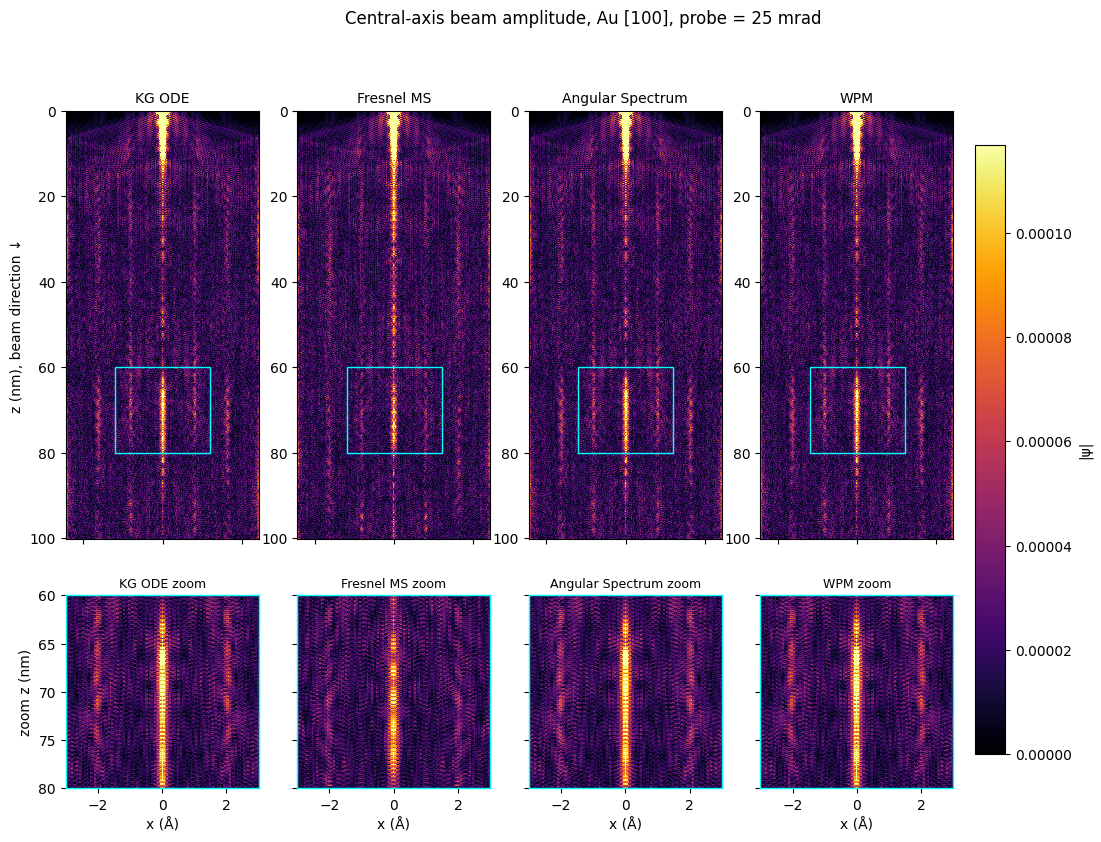

In [ ]:
# --- Cross-section controls -------------------------------------------------
CROSS_SECTION_PROBE_ANGLE_MRAD = 5.0          # which probe angle to slice
CROSS_SECTION_N_CELLS = n_unit_cells            # number of unit cells to propagate
CROSS_SECTION_SAVE_EVERY = 1                    # store amplitude every N slices (1 = every slice)
CROSS_SECTION_RESULTS_FILENAME = (
    f"cbed_cross_section_au100_{int(CROSS_SECTION_PROBE_ANGLE_MRAD):d}mrad.npz"
)
LOAD_EXISTING_CROSS_SECTION = True
RECOMPUTE_CROSS_SECTION = False
RUN_WPM_CROSS_SECTION = RUN_WPM

# Inset zoom: choose a depth window (nm) and a transverse window (Å)
INSET_Z_RANGE_NM = (60.0, 80.0)
INSET_X_RANGE_A = (-3.0, 3.0)
INSET_ROW_HEIGHT_RATIO = 1.35                   # zoom-row height relative to the main row

# --- Storage paths ---------------------------------------------------------
cross_section_path = resolve_repo_root() / "notebooks" / "cbed" / "results" / CROSS_SECTION_RESULTS_FILENAME

cross_section_methods = ["KG ODE", "Fresnel MS", "Angular Spectrum"] + (["WPM"] if RUN_WPM_CROSS_SECTION else [])


def _central_row_amplitude(wavefronts_jax):
    """Take central row amplitude from a stack of complex wavefronts of shape (N, ny, nx)."""
    arr = np.asarray(wavefronts_jax)
    return np.abs(arr[:, arr.shape[1] // 2, :]).astype(np.float32)


def _ensure_potentials_for_cross_section():
    """Rebuild one-cell potentials and Fresnel/AS kernels if they were skipped at load time."""
    global pot_ode_cell, pot_test_cell, fk, ak
    if pot_ode_cell is None:
        print("Building ODE one-cell potential for cross-section...")
        pot_ode_abtem = abtem.Potential(
            unit_supercell, gpts=ODE_GPTS, slice_thickness=dz_ode,
            projection="finite", parametrization="lobato",
        )
        pot_ode_cell = jnp.array(cupy.asnumpy(pot_ode_abtem.build(lazy=False).array) / dz_ode)
        del pot_ode_abtem
        cupy.get_default_memory_pool().free_all_blocks()
    if pot_test_cell is None:
        print("Building test one-cell potential for cross-section...")
        pot_test_abtem = abtem.Potential(
            unit_supercell, gpts=gpts, slice_thickness=dz_test,
            projection="finite", parametrization="lobato",
        )
        pot_test_cell = jnp.array(cupy.asnumpy(pot_test_abtem.build(lazy=False).array) / dz_test)
        del pot_test_abtem
        cupy.get_default_memory_pool().free_all_blocks()
        fk = jnp.array(fresnel_propagation_kernel(*gpts, sampling, z=dz_test, energy=energy))
        ak = jnp.array(angular_spectrum_propagation_kernel(*gpts, sampling, z=dz_test, energy=energy))


def _run_cross_section_simulation(n_cells, save_every):
    """Propagate one probe and return {method: (n_z, nx) amplitude}, z_axis_A, x_axis_A."""
    _ensure_potentials_for_cross_section()
    probe = make_convergent_probe(
        CROSS_SECTION_PROBE_ANGLE_MRAD, ny_g, nx_g, sampling[0], sampling[1], wavelength,
    )

    def _stride(stack):
        """Subsample along the slice axis."""
        return stack[::save_every]

    method_rows = {name: [] for name in cross_section_methods}
    # Initial (z = 0) row, identical for all methods
    initial_row = np.abs(np.asarray(probe)[ny_g // 2, :]).astype(np.float32)
    for name in cross_section_methods:
        method_rows[name].append(initial_row[None, :])

    # KG ODE
    print(f"Cross-section: KG ODE over {n_cells} unit cells ({ODE_SLICES_PER_CELL} slices/cell)...")
    wave_ode, phi_ode = probe, None
    for ci in range(n_cells):
        wave_ode, phi_ode, _, wavefronts = simulate_kg_ode_full(
            pot_ode_cell, wave_ode, dz_ode, energy, sampling,
            initial_phi=phi_ode, save_wavefronts=True,
        )
        method_rows["KG ODE"].append(_stride(_central_row_amplitude(wavefronts)))
        if (ci + 1) % 25 == 0 or (ci + 1) == n_cells:
            print(f"  KG ODE cell {ci + 1}/{n_cells}")
    cupy.get_default_memory_pool().free_all_blocks()

    # Fresnel + Angular Spectrum + WPM
    for method_name, runner in [
        ("Fresnel MS", lambda w: simulate_fresnel_as(pot_test_cell, w, fk, dz_test, energy)),
        ("Angular Spectrum", lambda w: simulate_fresnel_as(pot_test_cell, w, ak, dz_test, energy)),
        ("WPM", lambda w: simulate_wpm(pot_test_cell, w, dz_test, energy, sampling)) if RUN_WPM_CROSS_SECTION else None,
    ]:
        if runner is None:
            continue
        print(f"Cross-section: {method_name} over {n_cells} unit cells...")
        wave = probe
        for ci in range(n_cells):
            wave, _, wavefronts = runner(wave)
            method_rows[method_name].append(_stride(_central_row_amplitude(wavefronts)))
            if (ci + 1) % 25 == 0 or (ci + 1) == n_cells:
                print(f"  {method_name} cell {ci + 1}/{n_cells}")
        cupy.get_default_memory_pool().free_all_blocks()

    method_amplitudes = {name: np.concatenate(parts, axis=0) for name, parts in method_rows.items()}

    # z axis (Å). KG ODE has its own slicing (dz_ode); test methods use dz_test. Build both.
    n_ode_rows = method_amplitudes["KG ODE"].shape[0]
    n_test_rows = method_amplitudes["Fresnel MS"].shape[0]
    z_axis_ode_A = np.concatenate([[0.0], dz_ode * (np.arange(1, n_cells * ODE_SLICES_PER_CELL + 1)[(save_every - 1)::save_every])])
    z_axis_test_A = np.concatenate([[0.0], dz_test * (np.arange(1, n_cells * TEST_SLICES_PER_CELL + 1)[(save_every - 1)::save_every])])
    # Trim to actual stored lengths (in case of off-by-one with save_every).
    z_axis_ode_A = z_axis_ode_A[:n_ode_rows]
    z_axis_test_A = z_axis_test_A[:n_test_rows]

    x_axis_A = (np.arange(nx_g) - nx_g // 2) * sampling[1]
    return method_amplitudes, {"KG ODE": z_axis_ode_A}, z_axis_test_A, x_axis_A


# --- Load or compute ------------------------------------------------------
if (
    LOAD_EXISTING_CROSS_SECTION
    and cross_section_path.exists()
    and not RECOMPUTE_CROSS_SECTION
):
    with np.load(cross_section_path, allow_pickle=True) as cs_data:
        cross_section_amplitude = {str(name): cs_data[f"amplitude_{str(name).lower().replace(' ', '_')}"].copy()
                                   for name in cs_data["method_names"]}
        cross_section_methods = [str(name) for name in cs_data["method_names"]]
        cross_section_z_ode_A = cs_data["z_axis_ode_A"].copy()
        cross_section_z_test_A = cs_data["z_axis_test_A"].copy()
        cross_section_x_A = cs_data["x_axis_A"].copy()
        cross_section_meta = dict(cs_data["metadata"][0])
    print(f"Loaded cross-section -> {cross_section_path}")
else:
    cross_section_amplitude, z_ode_dict, cross_section_z_test_A, cross_section_x_A = (
        _run_cross_section_simulation(CROSS_SECTION_N_CELLS, CROSS_SECTION_SAVE_EVERY)
    )
    cross_section_z_ode_A = z_ode_dict["KG ODE"]
    cross_section_meta = {
        "probe_angle_mrad": float(CROSS_SECTION_PROBE_ANGLE_MRAD),
        "n_unit_cells": int(CROSS_SECTION_N_CELLS),
        "save_every": int(CROSS_SECTION_SAVE_EVERY),
        "energy_eV": float(energy),
        "wavelength_A": float(wavelength),
        "sampling_A": tuple(float(v) for v in sampling),
        "gpts": tuple(int(v) for v in gpts),
        "ode_slices_per_cell": int(ODE_SLICES_PER_CELL),
        "test_slices_per_cell": int(TEST_SLICES_PER_CELL),
    }
    cross_section_path.parent.mkdir(parents=True, exist_ok=True)
    save_arrays = {
        "method_names": np.array(cross_section_methods, dtype=object),
        "z_axis_ode_A": cross_section_z_ode_A,
        "z_axis_test_A": cross_section_z_test_A,
        "x_axis_A": cross_section_x_A,
        "metadata": np.array([cross_section_meta], dtype=object),
    }
    for name, arr in cross_section_amplitude.items():
        save_arrays[f"amplitude_{name.lower().replace(' ', '_')}"] = arr
    np.savez_compressed(cross_section_path, **save_arrays)
    print(f"Saved cross-section -> {cross_section_path}")


# --- Plot ----------------------------------------------------------------
from matplotlib.patches import Rectangle

# Common amplitude scale across methods (robust upper percentile)
all_vals = np.concatenate([a.ravel() for a in cross_section_amplitude.values()])
amp_vmax = float(np.percentile(all_vals, 99.5))
amp_vmin = 0.0

z_ranges_A = {name: cross_section_z_ode_A if name == "KG ODE" else cross_section_z_test_A
              for name in cross_section_methods}

# Inset bounds
z_inset_A = (10.0 * INSET_Z_RANGE_NM[0], 10.0 * INSET_Z_RANGE_NM[1])

n_panels = len(cross_section_methods)
fig, axes = plt.subplots(
    2,
    n_panels,
    figsize=(3.2 * n_panels + 1.0, 8.8),
    sharey=False,
    squeeze=False,
    gridspec_kw={"height_ratios": [3.0, INSET_ROW_HEIGHT_RATIO], "hspace": 0.18},
)
main_axes = axes[0]
zoom_axes = axes[1]

x_min, x_max = cross_section_x_A[0], cross_section_x_A[-1]
last_im = None
for col, method in enumerate(cross_section_methods):
    main_ax = main_axes[col]
    zoom_ax = zoom_axes[col]
    z_A = z_ranges_A[method]
    amp = cross_section_amplitude[method]
    extent = [x_min, x_max, z_A[-1] / 10.0, z_A[0] / 10.0]  # nm; flipped so top = entry
    im = main_ax.imshow(
        amp, extent=extent, origin="upper", aspect="auto",
        cmap="inferno", vmin=amp_vmin, vmax=amp_vmax, interpolation="nearest",
    )
    last_im = im
    main_ax.set_title(method, fontsize=10)
    if col == 0:
        main_ax.set_ylabel("z (nm), beam direction \u2193")
    main_ax.add_patch(
        Rectangle(
            (INSET_X_RANGE_A[0], INSET_Z_RANGE_NM[0]),
            INSET_X_RANGE_A[1] - INSET_X_RANGE_A[0],
            INSET_Z_RANGE_NM[1] - INSET_Z_RANGE_NM[0],
            fill=False,
            edgecolor="cyan",
            linewidth=1.0,
        )
    )

    zoom_ax.imshow(
        amp, extent=extent, origin="upper", aspect="auto",
        cmap="inferno", vmin=amp_vmin, vmax=amp_vmax, interpolation="nearest",
    )
    zoom_ax.set_xlim(INSET_X_RANGE_A)
    zoom_ax.set_ylim(z_inset_A[1] / 10.0, z_inset_A[0] / 10.0)  # flipped
    zoom_ax.set_title(f"{method} zoom", fontsize=9)
    zoom_ax.set_xlabel("x (Å)")
    if col == 0:
        zoom_ax.set_ylabel("zoom z (nm)")
    else:
        zoom_ax.set_yticklabels([])

for ax in main_axes:
    ax.set_xlabel("")
    ax.tick_params(labelbottom=False)

for ax in zoom_axes:
    for spine in ax.spines.values():
        spine.set_edgecolor("cyan")
        spine.set_linewidth(1.0)

fig.suptitle(
    f"Central-axis beam amplitude, Au [100], probe = {CROSS_SECTION_PROBE_ANGLE_MRAD:.0f} mrad",
    fontsize=12, y=0.995,
)
cbar = fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
cbar.set_label("|\u03c8|")
plt.show()


## Summary table

In [ ]:
print(f"Au [100], {energy/1e3:.0f} keV, final thickness = {actual_thickness_nm:.1f} nm")
print(f"Grid: {gpts}, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) Å")
print(f"ODE/test z-sampling: {ODE_SLICES_PER_CELL}/{TEST_SLICES_PER_CELL} slices per cell")

header = f"{'Angle (mrad)':>12s} {'Method':>18s} {'Final Rel RMSE':>14s} {'Mean runtime/cell (s)':>22s}"
print(header)
print("-" * len(header))
for alpha in PROBE_ANGLES_MRAD:
    angle_results = cbed_results["angles"][float(alpha)]
    for method in method_names:
        final_error = angle_results["rel_l2"][method][-1]
        mean_time = float(np.mean(angle_results["runtime_s"][method]))
        print(f"{alpha:>12.0f} {method:>18s} {final_error:>14.4e} {mean_time:>22.3f}")


Au [100], 200 keV, final thickness = 100.3 nm
Grid: (256, 256), sampling = (0.0478, 0.0478) Å
ODE/test z-sampling: 128/128 slices per cell
Angle (mrad)             Method Final Rel RMSE  Mean runtime/cell (s)
---------------------------------------------------------------------
          25         Fresnel MS     7.7958e-01                  0.214
          25   Angular Spectrum     1.1049e-01                  0.214
          25                WPM     2.4119e-02                  1.910
          50         Fresnel MS     7.9850e-01                  0.239
          50   Angular Spectrum     1.1741e-01                  0.233
          50                WPM     2.5797e-02                  1.983
         100         Fresnel MS     7.1368e-01                  0.212
         100   Angular Spectrum     1.0659e-01                  0.215
         100                WPM     2.4996e-02                  1.831
